In [9]:
import sys
from pathlib import Path
sys.path.append('..')

# Import the library
from src.cvh_cost import (
    CondoParams,
    HouseParams,
    SimulationParams,
    EconomicParams,
    EventConfig,
    compute_deterministic,
    run_monte_carlo,
    pv_to_monthly_savings,
)
from src.cvh_cost.reporting import format_text_report, plot_diff_distribution, plot_pv_distributions

import pandas as pd
import matplotlib.pyplot as plt

# For inline plots
%matplotlib inline

## 1. Define the Scenario

Let's set up a simple comparison:
- **Condo**: $450/month HOA fee with 2% annual escalation
- **House**: $400,000 value with 0.8% annual maintenance (routine) + major events modeled separately
- **Analysis**: 20 years at 3% discount rate

**Note**: This tool computes the **Present Value (PV) of ownership costs** for each option.
- Higher PV = more expensive to own over the analysis period
- The monthly savings figure shows how much you'd need to set aside each month to cover those costs
- We use 0.8% annual maintenance (not 1.5%) because major expenses like roof replacement are modeled as separate events

In [ ]:
# Define condo parameters
condo = CondoParams(
    monthly_fee=450,
    fee_escalation_rate=0.02,  # 2% annual increase
)

# Define house parameters with a roof replacement event
house = HouseParams(
    initial_value=400_000,
    value_growth_rate=0.03,  # annual appreciation of the home (affects maintenance)
    annual_maintenance_rate=0.012, # expected expense rate outisde of events
    events=[
        EventConfig(
            name="roof_replacement",
            base_cost=10_000,
            expected_year=20,
            timing_std_years=3,  # Could happen 3 years earlier or later
            cost_vol=0.25,  # 25% cost uncertainty
        ),
    ],
)

# Simulation parameters
sim = SimulationParams(
    years=20,
    discount_rate=0.03,  # 3% real discount rate
    num_sims=10_000,
    random_seed=42,
    house_maintenance_vol=0.25,  # 25% year-to-year maintenance volatility
    condo_fee_vol=0.05,  # 5% fee volatility
)

# Economic assumptions
econ = EconomicParams(mode="real")

print("Parameters defined successfully!")
print(f"  Condo monthly fee: ${condo.monthly_fee}")
print(f"  House value: ${house.initial_value:,}")
print(f"  House maintenance rate: {house.annual_maintenance_rate:.1%} (+ events)")
print(f"  Analysis period: {sim.years} years")

Parameters defined successfully!
  Condo monthly fee: $450
  House value: $400,000
  Analysis period: 20 years


## 2. Run Deterministic Analysis

First, let's compute the present value using fixed (non-random) parameters.

In [11]:
# Run deterministic calculation
det_result = compute_deterministic(condo, house, sim, econ)

# Calculate equivalent monthly savings needed
condo_monthly = pv_to_monthly_savings(det_result.condo_pv_total, sim.discount_rate, sim.years)
house_monthly = pv_to_monthly_savings(det_result.house_pv_total, sim.discount_rate, sim.years)
diff_monthly = pv_to_monthly_savings(abs(det_result.diff_pv), sim.discount_rate, sim.years)

# Display results
print("DETERMINISTIC RESULTS - Ownership Costs")
print("=" * 50)
print(f"\nCondo Total Cost PV:  ${det_result.condo_pv_total:>12,.0f}")
print(f"  - Monthly fees:     ${det_result.condo_pv_base:>12,.0f}")
print(f"  - Events:           ${det_result.condo_pv_events:>12,.0f}")
print(f"  - Other:            ${det_result.condo_pv_other:>12,.0f}")
print(f"  → Monthly savings needed: ${condo_monthly:,.0f}/mo")
print(f"\nHouse Total Cost PV:  ${det_result.house_pv_total:>12,.0f}")
print(f"  - Maintenance:      ${det_result.house_pv_base:>12,.0f}")
print(f"  - Events:           ${det_result.house_pv_events:>12,.0f}")
print(f"  - Other:            ${det_result.house_pv_other:>12,.0f}")
print(f"  → Monthly savings needed: ${house_monthly:,.0f}/mo")
print(f"\nCost Difference (House - Condo): ${det_result.diff_pv:,.0f}")
print(f"  → Extra monthly savings for house: ${diff_monthly:,.0f}/mo")
print("\n" + ("House" if det_result.diff_pv > 0 else "Condo") + " is more expensive in deterministic scenario")

DETERMINISTIC RESULTS - Ownership Costs

Condo Total Cost PV:  $      97,639
  - Monthly fees:     $      97,639
  - Events:           $           0
  - Other:            $           0
  → Monthly savings needed: $542/mo

House Total Cost PV:  $     102,860
  - Maintenance:      $      97,323
  - Events:           $       5,537
  - Other:            $           0
  → Monthly savings needed: $570/mo

Cost Difference (House - Condo): $5,221
  → Extra monthly savings for house: $29/mo

House is more expensive in deterministic scenario


## 3. Run Monte Carlo Simulation

Now let's run a simulation that accounts for uncertainty in costs and timing.

In [12]:
# Run Monte Carlo simulation
mc_result = run_monte_carlo(condo, house, sim, econ)

# Calculate monthly savings for MC mean values
condo_monthly_mc = pv_to_monthly_savings(mc_result.condo_summary.mean, sim.discount_rate, sim.years)
house_monthly_mc = pv_to_monthly_savings(mc_result.house_summary.mean, sim.discount_rate, sim.years)
diff_monthly_mc = pv_to_monthly_savings(abs(mc_result.diff_summary.mean), sim.discount_rate, sim.years)

print("MONTE CARLO RESULTS - Ownership Cost Distributions")
print("=" * 50)
print(f"Simulations: {sim.num_sims:,}")
print(f"\nCondo Ownership Cost PV:")
print(f"  Mean:    ${mc_result.condo_summary.mean:>10,.0f}  (~${condo_monthly_mc:,.0f}/mo)")
print(f"  Std:     ${mc_result.condo_summary.std:>10,.0f}")
print(f"  90% CI:  [${mc_result.condo_summary.p5:,.0f}, ${mc_result.condo_summary.p95:,.0f}]")
print(f"\nHouse Ownership Cost PV:")
print(f"  Mean:    ${mc_result.house_summary.mean:>10,.0f}  (~${house_monthly_mc:,.0f}/mo)")
print(f"  Std:     ${mc_result.house_summary.std:>10,.0f}")
print(f"  90% CI:  [${mc_result.house_summary.p5:,.0f}, ${mc_result.house_summary.p95:,.0f}]")
print(f"\nP(House costs more): {mc_result.prob_house_more_expensive:.1%}")
print(f"  → Mean extra monthly cost for house: ${diff_monthly_mc:,.0f}/mo")

MONTE CARLO RESULTS - Ownership Cost Distributions
Simulations: 10,000

Condo Ownership Cost PV:
  Mean:    $    97,628  (~$541/mo)
  Std:     $     1,082
  90% CI:  [$95,866, $99,415]

House Ownership Cost PV:
  Mean:    $   103,093  (~$572/mo)
  Std:     $     5,604
  90% CI:  [$93,810, $112,452]

P(House costs more): 83.0%
  → Mean extra monthly cost for house: $30/mo


## 4. Convert to DataFrame for Analysis

Let's create a pandas DataFrame for easier analysis.

In [13]:
# Create DataFrame from Monte Carlo results
df = pd.DataFrame({
    'condo_pv': mc_result.condo_pv,
    'house_pv': mc_result.house_pv,
    'diff_pv': mc_result.diff_pv,
})

# Add a flag for which is more expensive
df['house_more_expensive'] = df['diff_pv'] > 0

# Show summary statistics
print("DataFrame Summary:")
df.describe()

DataFrame Summary:


,condo_pv,house_pv,diff_pv
count,10000.000000,10000.000000,10000.000000
mean,97628.214703,103093.454208,5465.239505
std,1081.798117,5604.392505,5692.875997
min,93797.286377,83029.533764,-14338.789576
25%,96882.622853,99346.410783,1631.270210
50%,97623.183930,103120.419642,5508.294016
75%,98370.640367,106847.312594,9341.401903
max,101752.413689,127297.916195,29469.224114


## 5. Visualize Results

Let's create some visualizations to better understand the ownership cost distributions.

**Reading the plots:**
- The **difference plot** shows House Cost PV minus Condo Cost PV
- Positive values (right of break-even line) = House costs more
- Negative values (left of break-even line) = Condo costs more

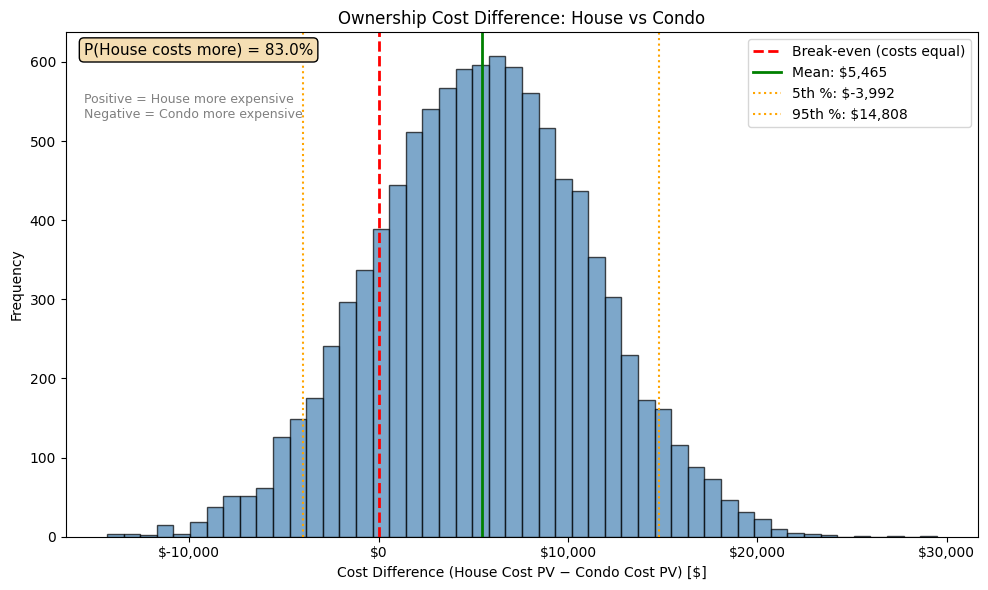

In [14]:
# Plot the difference distribution
fig = plot_diff_distribution(mc_result)
plt.show()

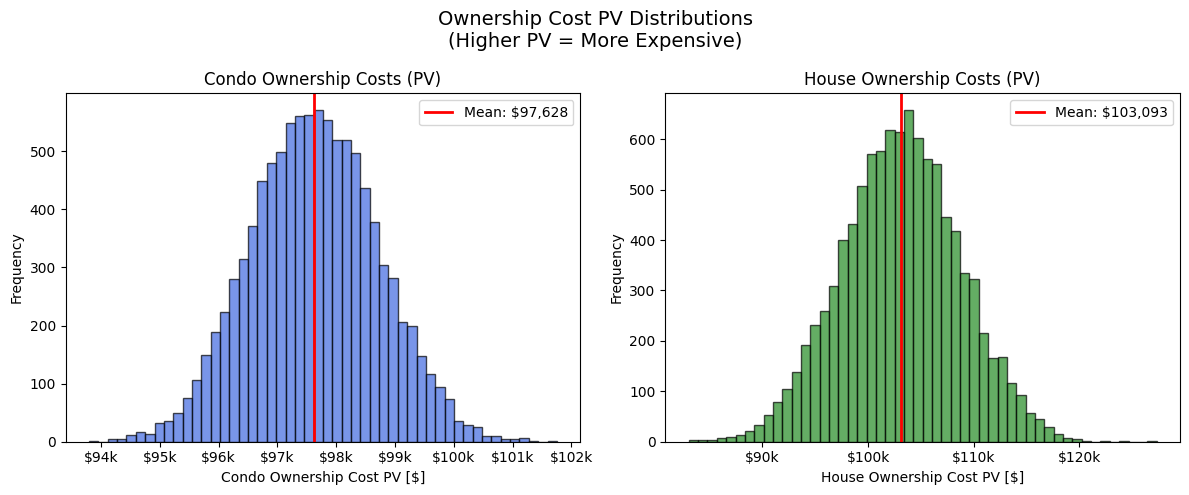

In [15]:
# Plot both PV distributions side by side
fig = plot_pv_distributions(mc_result)
plt.show()

## 6. Key Takeaways

Let's summarize our findings:

In [16]:
# Calculate key monthly figures
condo_monthly = pv_to_monthly_savings(det_result.condo_pv_total, sim.discount_rate, sim.years)
house_monthly = pv_to_monthly_savings(det_result.house_pv_total, sim.discount_rate, sim.years)
diff_monthly_det = pv_to_monthly_savings(abs(det_result.diff_pv), sim.discount_rate, sim.years)
diff_monthly_mc = pv_to_monthly_savings(abs(mc_result.diff_summary.mean), sim.discount_rate, sim.years)

print("KEY FINDINGS - Ownership Costs")
print("=" * 50)
print(f"\n1. Deterministic Cost Difference (PV): ${det_result.diff_pv:,.0f}")
print(f"   {'House' if det_result.diff_pv > 0 else 'Condo'} costs ${abs(det_result.diff_pv):,.0f} more over {sim.years} years")
print(f"   → That's ~${diff_monthly_det:,.0f}/mo extra savings needed")

print(f"\n2. Monte Carlo Mean Cost Difference (PV): ${mc_result.diff_summary.mean:,.0f}")
print(f"   With 90% CI: [${mc_result.diff_summary.p5:,.0f}, ${mc_result.diff_summary.p95:,.0f}]")
print(f"   → Mean extra monthly: ~${diff_monthly_mc:,.0f}/mo")

print(f"\n3. Probability that House costs more: {mc_result.prob_house_more_expensive:.1%}")

print(f"\n4. Monthly Savings Needed:")
print(f"   Condo:  ${condo_monthly:,.0f}/mo to cover ownership costs")
print(f"   House:  ${house_monthly:,.0f}/mo to cover ownership costs")

print(f"\n5. Uncertainty (Std Dev of Difference): ${mc_result.diff_summary.std:,.0f}")
print(f"   This represents the range of possible outcomes due to cost uncertainty")

# Conclusion
if mc_result.prob_house_more_expensive > 0.6:
    conclusion = "The house is likely to have higher ownership costs in most scenarios."
elif mc_result.prob_house_more_expensive < 0.4:
    conclusion = "The condo is likely to have higher ownership costs in most scenarios."
else:
    conclusion = "The ownership costs are fairly close - either could be more expensive."

print(f"\nCONCLUSION: {conclusion}")

KEY FINDINGS - Ownership Costs

1. Deterministic Cost Difference (PV): $5,221
   House costs $5,221 more over 20 years
   → That's ~$29/mo extra savings needed

2. Monte Carlo Mean Cost Difference (PV): $5,465
   With 90% CI: [$-3,992, $14,808]
   → Mean extra monthly: ~$30/mo

3. Probability that House costs more: 83.0%

4. Monthly Savings Needed:
   Condo:  $542/mo to cover ownership costs
   House:  $570/mo to cover ownership costs

5. Uncertainty (Std Dev of Difference): $5,693
   This represents the range of possible outcomes due to cost uncertainty

CONCLUSION: The house is likely to have higher ownership costs in most scenarios.


## Next Steps

- Try modifying the parameters to see how results change
- Add more events (HVAC, appliances, special assessments)
- Check out `advanced_usage.ipynb` for sensitivity analysis and multi-scenario comparisons
- Load configurations from YAML files using `load_config()`